# When a Result Is Real

*attribution, robustness, and the economic test*

## The question

Three ways to attack your own result, in increasing order of severity: ask **which feature
was actually carrying it**, ask **whether it survives being moved** to another parameter
setting or another regime, and finally ask whether it makes money — a test that has rejected
many models a p-value was happy with. A result that clears all three is worth reporting.

### Which feature was doing the work

[Forecasting the Smile](forecasting_the_smile.ipynb) reports every model's exact active-run skill against carry from one OOF ledger.
That leaves an obvious question whenever a candidate improves on carry: **what was the
model actually using?**

It matters for the argument. If the improvement comes from curvature — the rough model's own
second-order quantity — then rough volatility contributed something even though its exponent
was supported. If it comes from the level and its recent mean, the improvement is mean reversion
wearing a costume rather than evidence for the structural scaling law.

Along the way this is the general toolkit for opening a fitted model: permutation importance,
partial dependence, coefficient paths, and the unsupervised methods (PCA, clustering) that
describe the data without reference to any target.

### Does the model hold anywhere?

One escape route is left. The aggregate forecast score averaged over everything — all maturities, all
horizons, quiet days and violent ones. Perhaps rough features help *somewhere*: at a
particular H, a particular sampling frequency, or only after a large move.

That is a reasonable hypothesis and also a dangerous one, because searching for the place
where something works is exactly how spurious results are manufactured. Under the null, a grid of 30 cells
produces about 1.5 "significant" passes on average, and the
temptation to report the best cell is enormous.

So this notebook does both jobs at once: it runs the sweep properly — parallel, cached,
tidy — and then applies the corrections that decide whether anything in it survives.

### The hedging test, and reporting what you found

Every result so far has been about *forecasting* the smile. This notebook asks the question
that would have mattered even if all of them had gone the other way: **does the rough model
hedge better?**

That is a different and fairer test. A model can be wrong about the maturity exponent and
still produce a better delta, because hedging only needs the *local* sensitivity of implied
vol to spot — and rough volatility makes a specific claim about that.

The test has to be set up carefully. Identical paths, identical rebalance times, identical
costs; anything held unequal manufactures a winner. Then, finally, how to package a result
so someone else can act on it — including a result that says no.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
DATASET      = "smile_90d"
MIN_DTE, MAX_DTE = 7, 60
RESAMPLE_MIN = 5
TARGET       = "bf25"
HORIZON      = 1
N_REPEATS    = 5           # permutation-importance repeats
N_SAMPLE     = 20000       # subsample for the slower diagnostics
N_CLUSTERS   = 3
SEED         = 42
HURST_GRID   = (0.03, 0.05, 0.07, 0.10, 0.15, 0.20)
STEP_GRID    = (1, 5, 15, 30, 60)          # sampling frequency, minutes
MOVE_PCTS    = (10, 20, 30)                # 'active' = top X% of absolute moves
N_JOBS       = -1
USE_CACHE    = True
SWEEP_VERSION = "purged-v2"  # bump whenever evaluate_cell changes
N_PATHS      = 3000
N_STEPS      = 60          # rebalances over the option's life
MATURITY     = 0.25        # years
SPOT, STRIKE = 100.0, 100.0
SIGMA        = 0.25        # the flat vol the BS hedger uses
HURST, ETA, RHO, XI0 = 0.10, 1.5, -0.7, 0.0625
COST_BPS     = (0.0, 1.0, 5.0, 10.0, 25.0)

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
import numpy as np, pandas as pd
from rvlab.data import load_smile_panel
from rvlab.features import (add_lags, add_rolling, add_structural_coefficients,
                            make_target, resample_panel, supervised_frame)
from rvlab.pipelines import make_regression_pipeline

panel = resample_panel(load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE), RESAMPLE_MIN)
cols = ["atm_iv", "rr25", "bf25", "atm_total_var"]
df = make_target(add_rolling(add_lags(add_structural_coefficients(panel), cols, (1, 2)),
                             cols, windows=(5,), stats=("mean",)), TARGET, HORIZON)

features = ["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma",
            "bf25_lag1", "bf25_lag2", "rr25_lag1", "atm_iv_lag1", "bf25_mean5"]
X, y = supervised_frame(df, df.attrs["target"], [*features, "ts"])

times = np.sort(pd.to_datetime(X["ts"], utc=True).unique())
test_start = pd.Timestamp(times[int(len(times) * 0.7)])
purge = pd.Timedelta(minutes=(HORIZON + 1) * RESAMPLE_MIN)
train_mask = X["ts"] < test_start - purge
test_mask = X["ts"] >= test_start
X_train, X_test = X.loc[train_mask, features], X.loc[test_mask, features]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
assert not set(X.loc[train_mask, "ts"]) & set(X.loc[test_mask, "ts"])
assert X.loc[train_mask, "ts"].max() < X.loc[test_mask, "ts"].min()
model = make_regression_pipeline("ridge").fit(X_train, y_train)
print(f"train {X_train.shape} to {X.loc[train_mask, 'ts'].max()}")
print(f"test  {X_test.shape} from {X.loc[test_mask, 'ts'].min()} · shared timestamps 0")

train (52753, 12) to 2025-10-30 17:30:00+00:00
test  (23626, 12) from 2025-10-30 17:45:00+00:00 · shared timestamps 0


## Recipes in this notebook

**Which feature was doing the work**

| Recipe | What it does |
|---|---|
| [R4.1](#r4-1) | Rank features by permutation importance |
| [R4.2](#r4-2) | Read the coefficients of a linear model correctly |
| [R4.3](#r4-3) | Group correlated features before attributing credit |
| [R4.4](#r4-4) | Plot partial dependence to see the shape of an effect |
| [R4.5](#r4-5) | Trace a regularisation path |
| [R4.6](#r4-6) | Decompose the smile into level, slope and curvature with PCA |
| [R4.7](#r4-7) | Cluster observations into regimes |

**Does the model hold anywhere?**

| Recipe | What it does |
|---|---|
| [R4.8](#r4-8) | Write the cell function, then the grid |
| [R4.9](#r4-9) | Run the grid in parallel, with results cached to disk |
| [R4.10](#r4-10) | Turn a sweep into a matrix and look at it |
| [R4.11](#r4-11) | Report a pass rate honestly |
| [R4.12](#r4-12) | Condition on a regime — and control for the regime itself |
| [R4.13](#r4-13) | Check sensitivity to the choices you did not think about |
| [R4.14](#r4-14) | Record what a sweep actually ran |

**The hedging test, and reporting what you found**

| Recipe | What it does |
|---|---|
| [R4.15](#r4-15) | Compare the two deltas before backtesting either |
| [R4.16](#r4-16) | Backtest policies on identical paths |
| [R4.17](#r4-17) | Sweep transaction costs instead of assuming one |
| [R4.18](#r4-18) | Report the tail, not just the average |
| [R4.19](#r4-19) | Account for turnover, not just error |
| [R4.20](#r4-20) | Walk forward instead of splitting once |
| [R4.21](#r4-21) | Export the result so someone else can use it |
| [R4.22](#r4-22) | Write down the result, including when it is negative |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

This notebook is about adversarial checks on your own work, so the failure mode is subtler: the checks themselves can be run in ways that guarantee a pass.

**Python and pandas**

* **Permutation importance splits credit arbitrarily between correlated features.** Two
  copies of the same signal each look unimportant. Group them, or interpret at the group level.
* **Cache on a hash of the parameters, not on a filename you remember to bump.** A stale cache
  keyed by anything else is the most expensive bug in a sweep.
* **Seed per task inside a parallel map.** One global seed plus `joblib.Parallel` gives
  results that change with `n_jobs`, which is the kind of irreproducibility nobody looks for.
* **`joblib` closures capture whole frames.** Pass the columns needed, not the DataFrame.

**Analysis**

* **Score the same rows in sample and out of fold, side by side.** It is the cheapest real
  check available; the displayed gap, including whether the sign changes, measures optimism.
* **A regime computed over the full sample is look-ahead.** Estimate its threshold from each
  outer training fold (or update it from past observations online). A full-sample "high
  volatility" label quietly imports the future.
* **Turnover belongs in the result.** A hedge with lower error that trades twice as often is
  not better; report both or report neither.
* **The economic test can reject what statistics accept.** A model with respectable error
  metrics hedges worse than Black-Scholes delta *on its own simulated paths*. That is the test
  that settled it.


## Which feature was doing the work

Attribution: importance three ways, what to believe when they disagree, and the unsupervised structure sitting underneath the features.

## R4.1 · Rank features by permutation importance
<a id="r4-1"></a>

**Topic** Interpretability

**Use when** you want to know which inputs a fitted model relies on. Shuffle one column at a time in the *test* set and measure how much worse the model gets.

**Inputs** a fitted estimator, `X_test`, `y_test`.

**Needs** nothing beyond the setup and data cells

**Gotchas** correlated features share credit and each looks unimportant alone, because shuffling one leaves its twin intact. On this frame `bf25`, `bf25_lag1` and `bf25_mean5` are nearly the same information — read them as a block, not individually.

**See also** [R4.2](#r4-2) (coefficients) · [R4.3](#r4-3) (grouped importance)

In [4]:
import pandas as pd
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=N_REPEATS,
                              random_state=SEED, scoring="neg_root_mean_squared_error")
importance = (pd.DataFrame({"feature": features, "importance": perm.importances_mean,
                            "std": perm.importances_std})
              .sort_values("importance", ascending=False).set_index("feature"))
importance.round(6).head(8)

,importance,std
feature,,
bf25,3.4000e-04,2.0000e-06
bf25_mean5,1.7600e-04,2.0000e-06
bf25_lag1,1.0100e-04,2.0000e-06
alpha,8.9000e-05,1.0000e-06
rr25_lag1,4.4000e-05,2.0000e-06
atm_iv_lag1,2.6000e-05,1.0000e-06
bf25_lag2,1.4000e-05,1.0000e-06
gamma,9.0000e-06,1.0000e-06


The picture, with the rough-model features marked so the comparison is direct.

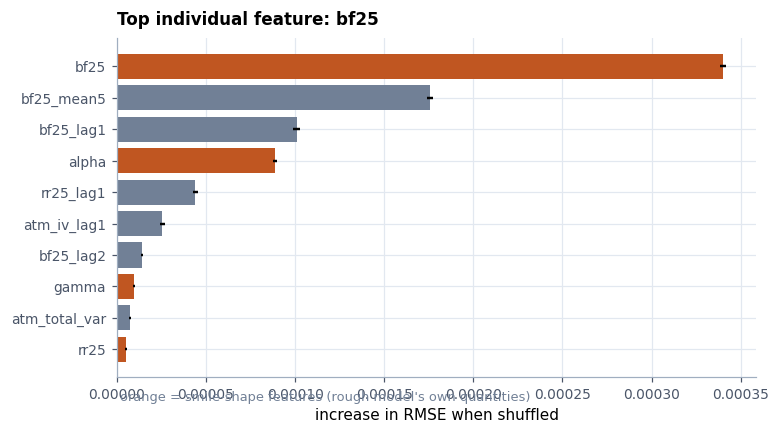

In [5]:
import matplotlib.pyplot as plt
from rvlab.plotting import C_BASELINE, C_MODEL, finish

top = importance.head(10).iloc[::-1]
colours = [C_MODEL if f in ("alpha", "gamma", "rr25", "bf25") else C_BASELINE
           for f in top.index]
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.barh(top.index, top["importance"], xerr=top["std"], color=colours)
finish(ax, f"Top individual feature: {importance.index[0]}", "increase in RMSE when shuffled", "",
       "orange = smile-shape features (rough model's own quantities)");

## R4.2 · Read the coefficients of a linear model correctly
<a id="r4-2"></a>

**Topic** Interpretability

**Use when** the model is linear. Coefficients are directly interpretable — but only after scaling, because a coefficient's size otherwise just reflects its feature's units.

**Inputs** a fitted pipeline whose final step is linear.

**Needs** R4.1 — run those first. This recipe builds on what they define.

**Gotchas** `set_output(transform='pandas')` in the pipeline is what makes this readable. Without it the coefficient vector is unlabelled and you have to reconstruct the order by hand.

**See also** [R4.1](#r4-1) (permutation) · [R3.4](forecasting_the_smile.ipynb#r3-4) (scaling inside the pipeline)

In [6]:
import pandas as pd

coefs = pd.Series(model.named_steps["model"].coef_, index=features, name="coefficient")
coefs.reindex(coefs.abs().sort_values(ascending=False).index).to_frame().round(5).head(8)

,coefficient
bf25,0.0010
bf25_mean5,0.0007
alpha,-0.0005
bf25_lag1,0.0005
rr25_lag1,0.0003
atm_iv_lag1,0.0002
bf25_lag2,0.0002
gamma,0.0001


Because the pipeline scales before fitting, these are comparable to each other. A large coefficient on a feature the permutation test called unimportant is the signature of collinearity — two features cancelling.

In [7]:
strong_but_unimportant = coefs.abs().sort_values(ascending=False).head(4).index
importance.loc[[f for f in strong_but_unimportant if f in importance.index]].round(6)

,importance,std
feature,,
bf25,3.4000e-04,2.0000e-06
bf25_mean5,1.7600e-04,2.0000e-06
alpha,8.9000e-05,1.0000e-06
bf25_lag1,1.0100e-04,2.0000e-06


## R4.3 · Group correlated features before attributing credit
<a id="r4-3"></a>

**Topic** Interpretability

**Use when** your features are collinear, so individual importances understate everything. Permuting a whole *block* together measures what that block contributes as a unit.

**Inputs** a fitted estimator and a mapping of block name to columns.

**Needs** R4.1 — run those first. This recipe builds on what they define.

**Gotchas** this is the honest version of the question 'does curvature matter?'. Asking it of `bf25` alone is answered by `bf25_lag1`; asking it of every curvature column at once is not.

**See also** [R4.1](#r4-1) (per-feature) · [R1.22](the_volatility_surface.ipynb#r1-22) (correlations)

In [8]:
import numpy as np, pandas as pd
from rvlab.evaluate import rmse

blocks = {
    "curvature (bf25 family)": ["bf25", "bf25_lag1", "bf25_lag2", "bf25_mean5"],
    "skew (rr25 family)":      ["rr25", "rr25_lag1"],
    "level (atm family)":      ["atm_iv", "atm_iv_lag1", "atm_total_var"],
    "rough structural":        ["alpha", "gamma"],
    "maturity":                ["T"],
}
base = rmse(y_test, model.predict(X_test))
print(f"baseline test RMSE {base:.6f}")

baseline test RMSE 0.000934


Permuting each block and re-scoring. The increase is what that block was worth to the model, credited as a unit.

In [9]:
rng = np.random.default_rng(SEED)
rows = []
for name, block in blocks.items():
    shuffled = X_test.copy()
    for col in block:
        shuffled[col] = rng.permutation(shuffled[col].to_numpy())
    rows.append({"block": name, "rmse_when_shuffled": rmse(y_test, model.predict(shuffled)),
                 "damage": rmse(y_test, model.predict(shuffled)) - base})
pd.DataFrame(rows).set_index("block").sort_values("damage", ascending=False).round(6)

,rmse_when_shuffled,damage
block,,
curvature (bf25 family),0.0019,9.1800e-04
rough structural,0.0010,1.0400e-04
skew (rr25 family),0.0010,3.5000e-05
level (atm family),0.0010,3.0000e-05
maturity,0.0009,1.0000e-06


## R4.4 · Plot partial dependence to see the shape of an effect
<a id="r4-4"></a>

**Topic** Interpretability

**Use when** importance says *how much*; partial dependence says *in which direction and what shape*. ICE curves add the per-observation spread, which reveals interactions that the average hides.

**Inputs** a fitted estimator and `X_test`.

**Needs** nothing beyond the setup and data cells

**Gotchas** partial dependence extrapolates: it evaluates the model at feature combinations that never occur in the data. Where the feature is strongly correlated with others, the curve's tails are model artefacts rather than findings.

**See also** [R4.1](#r4-1) (importance) · [R4.3](#r4-3) (blocks)

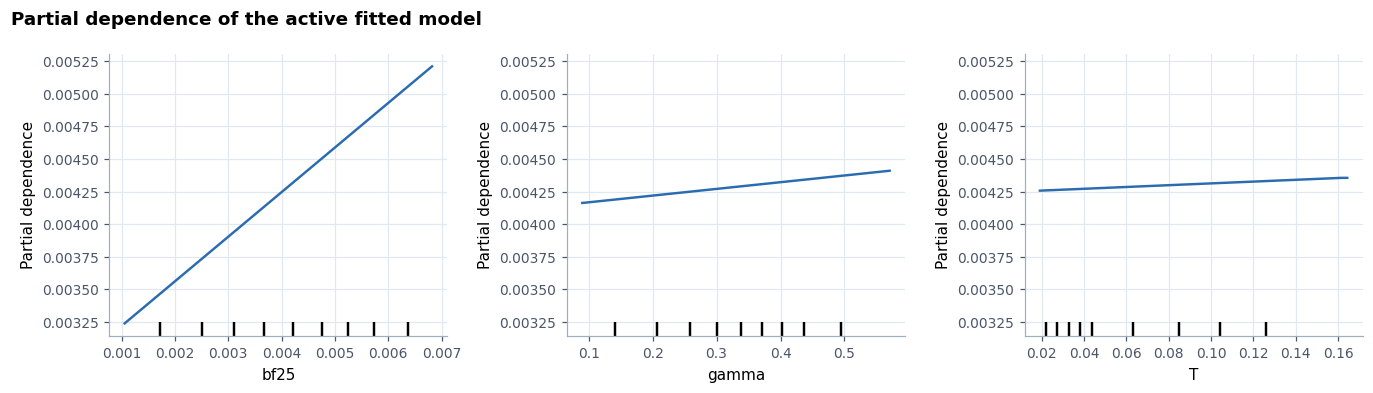

In [10]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

sample = X_test.sample(min(N_SAMPLE, len(X_test)), random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
PartialDependenceDisplay.from_estimator(model, sample, ["bf25", "gamma", "T"],
                                        ax=axes, kind="average")
fig.suptitle("Partial dependence of the active fitted model",
             x=0.005, ha="left", fontsize=12, fontweight="600")
fig.tight_layout();

Read the plotted direction and the two slopes below rather than assuming persistence or mean reversion in advance.

Partial dependence moves **one** feature and holds the rest fixed. Here `bf25`, `bf25_lag1` and `bf25_mean5` are nearly the same information, so varying `bf25` alone while pinning its siblings at their medians measures only the share of the effect that this one column carries. The quantity you usually mean by 'does it predict persistence?' is the effect of moving the whole block.

In [11]:
import numpy as np, pandas as pd

lo, hi = X_test["bf25"].quantile([0.1, 0.9])
grid = X_test.median().to_frame().T
partial = np.diff([model.predict(grid.assign(bf25=v))[0] for v in (lo, hi)])[0] / (hi - lo)

block = ["bf25", "bf25_lag1", "bf25_lag2", "bf25_mean5"]
total = np.diff([model.predict(grid.assign(**{c: v for c in block}))[0]
                 for v in (lo, hi)])[0] / (hi - lo)

print(f"moving bf25 alone            : slope {partial:.3f}")
print(f"moving the whole bf25 family : slope {total:.3f}   (1.0 would be pure carry)")

moving bf25 alone            : slope 0.342
moving the whole bf25 family : slope 0.815   (1.0 would be pure carry)


## R4.5 · Trace a regularisation path
<a id="r4-5"></a>

**Topic** Model selection

**Use when** you want to know which features survive as a penalty tightens. The order in which coefficients are driven to zero is a robust ranking, and one that is far less fooled by collinearity than a single fit.

**Inputs** `X_train`, `y_train`.

**Needs** nothing beyond the setup and data cells

**Gotchas** the path is on *standardised* features, so ordering is meaningful. A feature that survives to a high penalty is carrying information no other feature has.

**See also** [R4.2](#r4-2) (coefficients) · [R3.13](forecasting_the_smile.ipynb#r3-13) (choosing the penalty)

In [12]:
import numpy as np, pandas as pd
from sklearn.linear_model import lasso_path
from sklearn.preprocessing import StandardScaler

Z = StandardScaler().fit_transform(X_train.fillna(X_train.median()))
alphas, coefs, _ = lasso_path(Z, y_train - y_train.mean(), n_alphas=40)

survival = pd.Series({features[i]: alphas[np.nonzero(coefs[i])[0]].max()
                      if np.any(coefs[i]) else 0.0 for i in range(len(features))},
                     name="largest alpha at which it survives")
survival.sort_values(ascending=False).to_frame().head(6).round(6)

,largest alpha at which it survives
bf25_mean5,1.4310e-03
bf25,1.1990e-03
alpha,3.4700e-04
bf25_lag1,3.4700e-04
atm_iv,2.4000e-05
T,1.4000e-05


Reading the path visually shows *when* each coefficient enters, which is the part a table of final coefficients cannot tell you.

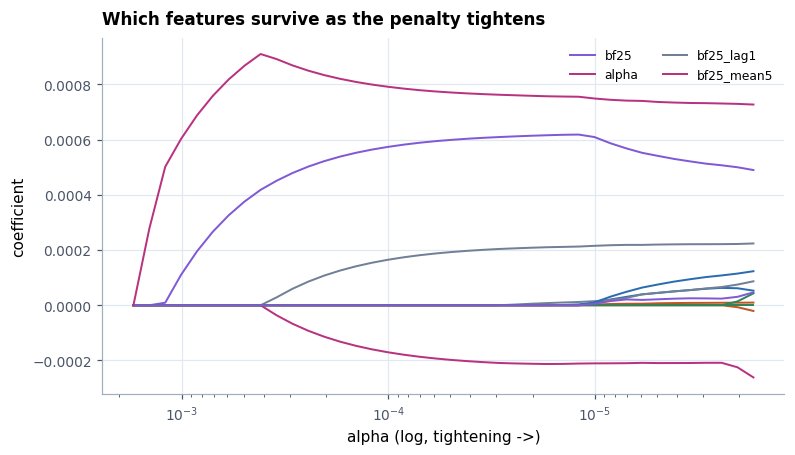

In [13]:
import matplotlib.pyplot as plt
from rvlab.plotting import PALETTE, finish

fig, ax = plt.subplots()
for i, name in enumerate(features):
    ax.plot(alphas, coefs[i], color=PALETTE[i % len(PALETTE)], lw=1.3,
            label=name if survival[name] > alphas[len(alphas)//2] else None)
ax.set_xscale("log"); ax.invert_xaxis(); ax.legend(fontsize=8, ncols=2)
finish(ax, "Which features survive as the penalty tightens", "alpha (log, tightening ->)",
       "coefficient");

## R4.6 · Decompose the smile into level, slope and curvature with PCA
<a id="r4-6"></a>

**Topic** Dimensionality

**Use when** you want the data's own structure, with no target involved. PCA on a term structure almost always recovers level, slope and curvature as the first three components — the classic fixed-income decomposition, and it works here too.

**Inputs** a wide matrix: rows = timestamps, columns = maturity buckets.

**Needs** nothing beyond the setup and data cells

**Gotchas** **standardise first, and know why.** PCA on unstandardised columns is dominated by whichever has the largest variance, which is a units artefact rather than a finding.

**See also** [R1.22](the_volatility_surface.ipynb#r1-22) (correlations) · [R4.7](#r4-7) (regimes)

In [14]:
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Quantile buckets, not fixed edges: fixed edges leave some buckets unpopulated
# whenever the panel quotes a different set of expiries, and the dropna() below
# then removes every row.
n_buckets = min(5, df["T"].nunique())
wide = (df.assign(bucket=pd.qcut(df["T"] * 365, n_buckets, duplicates="drop").astype(str))
        .pivot_table(index="ts", columns="bucket", values="atm_iv", aggfunc="mean")
        .dropna(axis=1, thresh=int(0.5 * df["ts"].nunique()))
        .dropna())
print(f"{wide.shape[0]:,} timestamps x {wide.shape[1]} maturity buckets")
n_comp = min(3, wide.shape[1])
pca = PCA(n_components=n_comp).fit(StandardScaler().fit_transform(wide))
pd.Series(pca.explained_variance_ratio_, index=[f"PC{i+1}" for i in range(n_comp)],
          name="variance explained").to_frame().round(4)

6,557 timestamps x 5 maturity buckets


,variance explained
PC1,0.9616
PC2,0.0240
PC3,0.0075


The explained-variance table says how concentrated this active term structure is. Interpret the loadings rather than naming components by position alone: a flat same-signed vector is a level shift, a sign change is a tilt, and a hump is curvature.

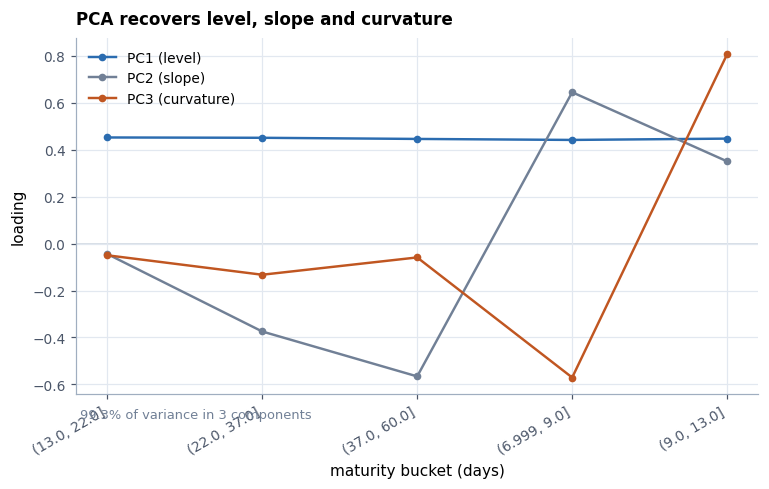

In [15]:
import matplotlib.pyplot as plt
from rvlab.plotting import PALETTE, finish

labels = ["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"]
fig, ax = plt.subplots()
for i in range(pca.n_components_):
    ax.plot(range(wide.shape[1]), pca.components_[i], marker="o",
            color=PALETTE[i], label=labels[i])
ax.set_xticks(range(wide.shape[1]), wide.columns, rotation=30, ha="right")
ax.axhline(0, color="#cbd5e0", lw=1, zorder=0); ax.legend()
finish(ax, "PCA recovers level, slope and curvature", "maturity bucket (days)", "loading",
       f"{pca.explained_variance_ratio_.sum():.1%} of variance in "
       f"{pca.n_components_} components");

## R4.7 · Cluster observations into regimes
<a id="r4-7"></a>

**Topic** Unsupervised

**Use when** you suspect the data contains distinct states and want to label them without supervision. K-means is the blunt tool; a Gaussian mixture gives soft assignments and handles elongated clusters better.

**Inputs** a scaled feature frame.

**Needs** nothing beyond the setup and data cells

**Gotchas** clustering **always** returns clusters. The silhouette score and a comparison against clustered noise are the minimum checks before calling them regimes rather than arbitrary partitions.

**See also** [R4.12](when_a_result_is_real.ipynb#r4-12) (conditioning on regimes) · [R4.6](#r4-6) (PCA)

In [16]:
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

state_cols = ["atm_iv", "rr25", "bf25"]
sample = df[state_cols].dropna().sample(min(N_SAMPLE, len(df)), random_state=SEED)
Z = StandardScaler().fit_transform(sample)

labels = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=SEED).fit_predict(Z)
print(f"silhouette {silhouette_score(Z, labels, sample_size=5000, random_state=SEED):.4f}")
sample.assign(regime=labels).groupby("regime").agg(["median", "size"]).round(4)

silhouette 0.3914


atm_iv          rr25          bf25      
        median  size  median  size  median  size
regime                                          
0       0.1198  8359 -0.0354  8359  0.0033  8359
1       0.1330  8527 -0.0481  8527  0.0062  8527
2       0.1715  3114 -0.0657  3114  0.0054  3114

> ⚠️ **Clustering always succeeds:** the control is to run the same procedure on data with no cluster structure at all and compare the scores. If they are similar, the partition is describing the shape of a single blob.

In [17]:
rng = np.random.default_rng(SEED)
noise = rng.standard_normal(Z.shape)
noise_labels = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=SEED).fit_predict(noise)
print(f"silhouette on active data: "
      f"{silhouette_score(Z, labels, sample_size=5000, random_state=SEED):.4f}")
print(f"silhouette on pure noise: "
      f"{silhouette_score(noise, noise_labels, sample_size=5000, random_state=SEED):.4f}")

silhouette on active data: 0.3914
silhouette on pure noise: 0.2112


## Does the model hold anywhere?

Moving the result — across parameters, across sampling frequencies, across regimes — and watching what happens to it. The in-sample and out-of-fold answers are shown together so any gap or sign change is visible.

Its data cell binds `df`.

In [18]:
from rvlab.data import describe_provenance, load_smile_panel

df = load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE)
print(describe_provenance(df))

smile_90d: 380,857 rows from /Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0b_days90_farF.pkl | 2025-08-07 13:35:00+00:00 -> 2025-12-12 19:55:00+00:00


## R4.8 · Write the cell function, then the grid
<a id="r4-8"></a>

**Topic** Experiment design

**Use when** any parameter study. Write one function that evaluates a *single* cell and returns a dict of scalars. The grid, the parallelism and the caching then come for free.

**Inputs** `df`, and the parameters to sweep.

**Needs** nothing beyond the setup and data cells

**Gotchas** the cell function must be a plain top-level function of its arguments — no reliance on notebook state. That is what makes it cacheable and parallelisable, and it is the same discipline that makes the recipes in this series copy-pasteable.

**See also** [R4.9](#r4-9) (running it) · [R3.15](forecasting_the_smile.ipynb#r3-15) (the single-cell version)

In [19]:
import warnings, numpy as np, pandas as pd
from sklearn.base import clone
from rvlab.evaluate import rmse, skill_vs_baseline
from rvlab.features import make_target, resample_panel, supervised_frame
from rvlab.models.baselines import CarryConditionedRough, CarryForecaster, RoughStructuralForecaster
from rvlab.pipelines import GroupTimeSeriesSplit

def evaluate_cell(hurst, step_min, panel, target=TARGET, n_splits=3, cache_version=SWEEP_VERSION):
    thinned = make_target(resample_panel(panel, step_min), target, 1)
    X, y = supervised_frame(thinned, thinned.attrs["target"],
                            ["T", "atm_iv", "atm_total_var", "rr25", "bf25", "ts", "expiry"])
    if len(X) < 500 or X["ts"].nunique() < 40: return None

    models = {"carry": CarryForecaster(level_col=target),
              "rough": RoughStructuralForecaster(target=target, hurst=hurst),
              "rough_cond_carry": CarryConditionedRough(target=target, hurst=hurst)}
    oof = {n: np.full(len(X), np.nan) for n in models}
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r"The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
        folds = list(GroupTimeSeriesSplit(n_splits=n_splits, embargo=pd.Timedelta(minutes=2 * int(step_min))).split(X))
    for tr, te in folds:
        for name, m in models.items():
            oof[name][te] = clone(m).fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])

    ok = ~np.isnan(oof["carry"])
    return {"n_scored": int(ok.sum()), "carry_rmse": rmse(y[ok], oof["carry"][ok]),
            "skill_rough": skill_vs_baseline(y[ok], oof["rough"][ok], oof["carry"][ok]),
            "skill_cond": skill_vs_baseline(y[ok], oof["rough_cond_carry"][ok], oof["carry"][ok])}

Test one cell before launching thirty. A sweep that fails on cell 27 after nine minutes is the most avoidable waste in this kind of work.

In [20]:
probe = evaluate_cell(hurst=0.10, step_min=5, panel=df)
probe

{'n_scored': 57278,
 'carry_rmse': 0.001031421277610999,
 'skill_rough': -2.0180028620177994,
 'skill_cond': -0.03280763871345127}

## R4.9 · Run the grid in parallel, with results cached to disk
<a id="r4-9"></a>

**Topic** Experiment infrastructure

**Use when** the grid is large or slow. `run_grid` builds the Cartesian product, farms it out with joblib, and memoises each cell so a re-run costs nothing.

**Inputs** the cell function from [R4.8](#r4-8) and a parameter grid.

**Needs** R4.8 — run those first. This recipe builds on what they define.

**Gotchas** the cache keys on the *arguments*, so editing the body of `evaluate_cell` without clearing the cache silently returns stale results. Call `clear_cache()` whenever the function changes — this is the single most common way a cached sweep lies to you.

**See also** [R4.8](#r4-8) (the cell) · [R4.10](#r4-10) (reading it)

In [21]:
from rvlab.evaluate import run_grid

results = run_grid(evaluate_cell, {"hurst": list(HURST_GRID), "step_min": list(STEP_GRID)},
                   panel=df, cache_version=SWEEP_VERSION, n_jobs=N_JOBS, cache=USE_CACHE)
print(f"{len(results)} of {results.attrs['n_cells']} cells evaluated")
results.head()

30 of 30 cells evaluated


,hurst,step_min,n_scored,carry_rmse,skill_rough,skill_cond
0,0.03,1,284720,0.0008,-3.3004,-0.0050
1,0.03,5,57278,0.0010,-2.1351,-0.0180
2,0.03,15,18473,0.0013,-1.4910,-0.0420
3,0.03,30,8788,0.0014,-1.3079,-0.0656
4,0.03,60,4341,0.0017,-0.8851,-0.0509


Check for failures before interpreting anything. `run_grid` records an `error` column rather than letting one bad cell abort the sweep — which is right, and also means a silently half-empty grid is possible.

In [22]:
if "error" in results.columns:
    print(results[results["error"].notna()][["hurst", "step_min", "error"]].to_string())
else:
    print("no cell errors")

no cell errors


## R4.10 · Turn a sweep into a matrix and look at it
<a id="r4-10"></a>

**Topic** Visualisation

**Use when** you have a tidy sweep and want to see the shape of the result. Pivot to a matrix and plot it diverging around zero, so the sign — the actual finding — is visible.

**Inputs** `results` from [R4.9](#r4-9).

**Needs** R4.8, R4.9 — run those first. This recipe builds on what they define.

**Gotchas** diverging, not sequential. On a skill score the question is whether a cell is above or below zero, and a sequential colour map hides exactly that boundary.

**See also** [R4.9](#r4-9) (the sweep) · [R4.11](#r4-11) (whether it means anything)

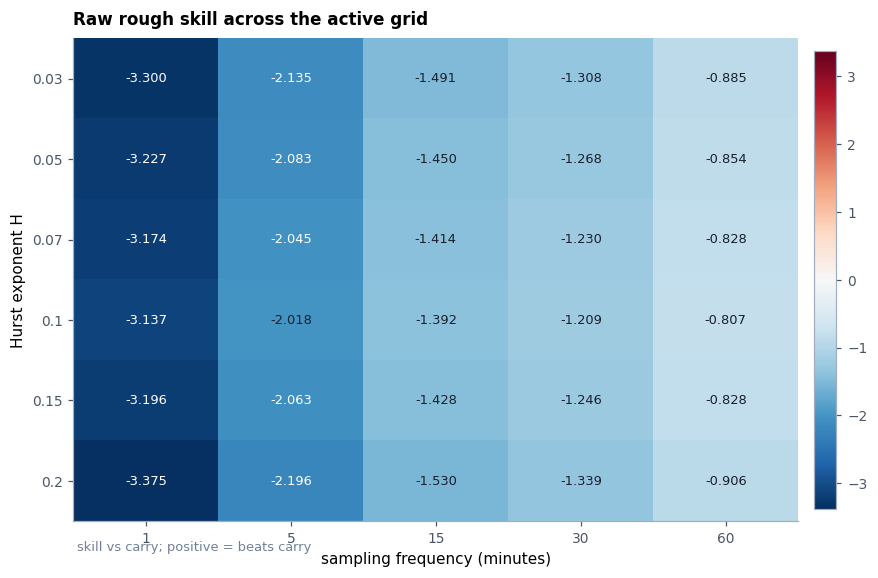

In [23]:
from rvlab.evaluate import sweep_matrix
from rvlab.plotting import sweep_heatmap

matrix = sweep_matrix(results, row="hurst", col="step_min", value="skill_rough")
sweep_heatmap(matrix, center=0.0, title="Raw rough skill across the active grid",
              xlabel="sampling frequency (minutes)", ylabel="Hurst exponent H",
              note="skill vs carry; positive = beats carry");

The conditioned form is a separate candidate. Same active data, same grid and axes, different model; its sign is read from the plot and pass-rate table rather than from a historical record.

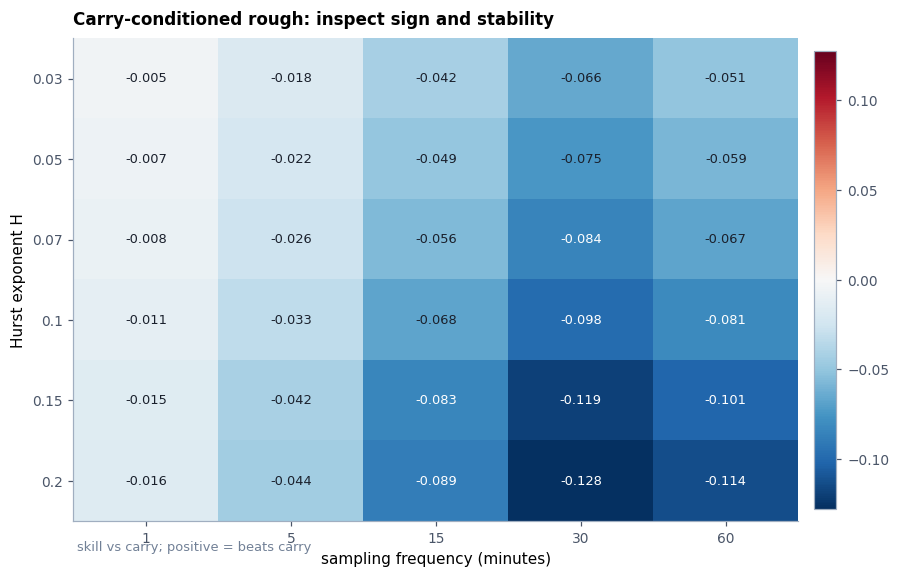

In [24]:
from rvlab.evaluate import sweep_matrix
from rvlab.plotting import sweep_heatmap

sweep_heatmap(sweep_matrix(results, "hurst", "step_min", "skill_cond"), center=0.0,
              title="Carry-conditioned rough: inspect sign and stability",
              xlabel="sampling frequency (minutes)", ylabel="Hurst exponent H",
              note="skill vs carry; positive = beats carry");

## R4.11 · Report a pass rate honestly
<a id="r4-11"></a>

**Topic** Multiplicity

**Use when** the sweep is done and some cells look good. 'k of n cells passed' is a descriptive statistic, not evidence — the comparison it needs is against how many would pass by chance.

**Inputs** `results` with a skill column.

**Needs** R4.8, R4.9 — run those first. This recipe builds on what they define.

**Gotchas** a pass rate above the chance rate is *suggestive*. It is not significance, because the cells are not independent — they share data — so the effective number of tests is smaller than n and no simple correction is exactly right.

**See also** [R3.21](forecasting_the_smile.ipynb#r3-21) (BH and Bonferroni) · [R4.12](#r4-12) (regimes)

In [25]:
import pandas as pd
from rvlab.evaluate import summarise_sweep

pd.concat([summarise_sweep(results, "skill_rough").assign(model="rough"),
           summarise_sweep(results, "skill_cond").assign(model="rough_cond_carry")]
          ).set_index("model").round(4)

,n_cells,n_pass,pass_rate,median,p25,p75
model,,,,,,
rough,30,0,0.0,-1.4388,-2.1221,-1.2344
rough_cond_carry,30,0,0.0,-0.0536,-0.0826,-0.0230


The honest framing states the descriptive pass rate and the sample it came from. Dependence across grid cells means a null rate needs a family-level procedure, not an assumed 50% benchmark.

In [26]:
import numpy as np

for col, label in [("skill_rough", "raw rough"), ("skill_cond", "carry-conditioned")]:
    passed = (results[col] > 0).sum()
    print(f"{label:20s}: {passed} of {len(results)} cells beat carry "
          f"({passed / len(results):.0%} descriptive pass rate)")

raw rough           : 0 of 30 cells beat carry (0% descriptive pass rate)
carry-conditioned   : 0 of 30 cells beat carry (0% descriptive pass rate)


## R4.12 · Condition on a regime — and control for the regime itself
<a id="r4-12"></a>

**Topic** Conditional analysis

**Use when** the hypothesis is that a signal works only in particular states. Split the sample by a regime indicator and score within each.

**Inputs** `df`, and a definition of 'active'.

**Needs** nothing beyond the setup and data cells

**Gotchas** two things must be right, not one. Both the state variable and its threshold must be causal: a lagged move compared with a full-sample percentile still looks ahead. Fit each threshold on the preceding outer training fold, then score with the label horizon purged.

**See also** [R4.7](when_a_result_is_real.ipynb#r4-7) (clustering regimes) · [R3.2](forecasting_the_smile.ipynb#r3-2) (leak taxonomy)

In [27]:
import numpy as np, pandas as pd
from rvlab.features import resample_panel

thinned = resample_panel(df, 5).sort_values(["expiry", "ts"]).copy()
# The move is measured from the PREVIOUS bar, so the label is known before the
# bar it conditions on.
thinned["prev_move"] = (thinned.groupby("expiry", observed=True)["atm_iv"]
                        .diff().abs().groupby(thinned["expiry"]).shift(1))

print(f"causal move observations: {thinned['prev_move'].notna().sum():,}; "
      "regime cutoffs are fitted inside each outer training fold")

causal move observations: 76,501; regime cutoffs are fitted inside each outer training fold


Now score the conditioned model separately in active and quiet states — twice. Each active-state cutoff is estimated only from the preceding outer training fold. The in-sample and out-of-fold predictions are then compared on those same held-out regime rows.

In [28]:
import numpy as np, pandas as pd
from sklearn.base import clone
from rvlab.evaluate import skill_vs_baseline
from rvlab.features import make_target, supervised_frame
from rvlab.models.baselines import CarryConditionedRough, CarryForecaster
from rvlab.pipelines import GroupTimeSeriesSplit

lab = make_target(thinned, TARGET, 1)
X, y = supervised_frame(lab, lab.attrs["target"],
    ["T", "atm_iv", "atm_total_var", "rr25", "bf25", "prev_move",
     "ts", "expiry"])

carry_in = CarryForecaster(level_col=TARGET).fit(X, y).predict(X)
cond_in = CarryConditionedRough(target=TARGET, hurst=0.10).fit(X, y).predict(X)
print(f"in-sample skill over the whole panel: {skill_vs_baseline(y, cond_in, carry_in):+.4f}")

in-sample skill over the whole panel: +0.0287


The same model, the same rows, scored out of fold instead.

In [29]:
carry_oof, cond_oof = np.full(len(X), np.nan), np.full(len(X), np.nan)
regime_oof = {p: np.zeros(len(X), dtype=bool) for p in MOVE_PCTS}
regime_cutoffs = []
cv = GroupTimeSeriesSplit(n_splits=4,
                          embargo=pd.Timedelta(minutes=2 * RESAMPLE_MIN))
for fold, (tr, te) in enumerate(cv.split(X)):
    train_moves = X.iloc[tr].groupby("ts", observed=True)["prev_move"].median()
    for p in MOVE_PCTS:
        cutoff = float(train_moves.quantile(1 - p / 100))
        regime_oof[p][te] = X.iloc[te]["prev_move"].to_numpy() >= cutoff
        regime_cutoffs.append({"fold": fold, "top_pct": p, "cutoff": cutoff})
    carry_oof[te] = clone(CarryForecaster(level_col=TARGET)).fit(
        X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
    cond_oof[te] = clone(CarryConditionedRough(target=TARGET, hurst=0.10)).fit(
        X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])

ok = ~np.isnan(cond_oof)
overall_oof_skill = skill_vs_baseline(y[ok], cond_oof[ok], carry_oof[ok])
print(f"out-of-fold skill over the whole panel: {overall_oof_skill:+.4f}")
pd.DataFrame(regime_cutoffs).pivot(index="fold", columns="top_pct", values="cutoff").round(5)

out-of-fold skill over the whole panel: -0.0023


top_pct,10,20,30
fold,,,
0,0.0013,0.0006,0.0004
1,0.0013,0.0006,0.0004
2,0.0016,0.0008,0.0005
3,0.0018,0.0009,0.0006


> ⚠️ **In-sample selection:** the out-of-fold column is the one to report. The gap between the two columns measures optimism; do not assume in advance that it must flip the sign.

Now the regime breakdown, using the training-fold cutoffs and the same scored rows in both columns.

In [30]:
rows = []
for p in MOVE_PCTS:
    for label, mask in [(f"active top {p}%", regime_oof[p] & ok),
                        (f"quiet (rest of {p}%)", ~regime_oof[p] & ok)]:
        rows.append({"regime": label, "n": int(mask.sum()),
                     "skill_in_sample": round(skill_vs_baseline(
                         y[mask], cond_in[mask], carry_in[mask]), 4),
                     "skill_out_of_fold": round(skill_vs_baseline(
                         y[mask], cond_oof[mask], carry_oof[mask]), 4)})
regime_results = pd.DataFrame(rows)
regime_results

,regime,n,skill_in_sample,skill_out_of_fold
0,active top 10%,14179,0.0209,-0.0403
1,quiet (rest of 10%),46974,0.0312,0.0149
2,active top 20%,22187,0.0265,-0.0217
3,quiet (rest of 20%),38966,0.0294,0.0148
4,active top 30%,27415,0.0279,-0.0148
5,quiet (rest of 30%),33738,0.0282,0.0142


## R4.13 · Check sensitivity to the choices you did not think about
<a id="r4-13"></a>

**Topic** Robustness

**Use when** your result depends on decisions you made without much thought — a tenor filter, a winsorizing quantile, a fold count. Vary them and see whether the conclusion moves.

**Inputs** `df` and the cell function.

**Needs** R4.8 — run those first. This recipe builds on what they define.

**Gotchas** a result that survives only at one setting of an arbitrary parameter is a property of that setting. This is the cheapest robustness check there is and the one most often skipped.

**See also** [R4.11](#r4-11) (pass rates) · [R4.9](#r4-9) (the sweep machinery)

In [31]:
import pandas as pd
from rvlab.evaluate import run_grid

tenor_results = run_grid(
    lambda max_dte, hurst: evaluate_cell(hurst=hurst, step_min=5,
                                         panel=df[df["T"] * 365 <= max_dte]),
    {"max_dte": [21, 35, 60], "hurst": [0.05, 0.10, 0.20]},
    n_jobs=N_JOBS, cache=False)
tenor_results[["max_dte", "hurst", "skill_rough", "skill_cond"]].round(4)

,max_dte,hurst,skill_rough,skill_cond
0,21,0.05,-1.4987,-0.0198
1,21,0.10,-1.4919,-0.0218
2,21,0.20,-1.5133,-0.0252
3,35,0.05,-1.8279,-0.0241
4,35,0.10,-1.7940,-0.0305
5,35,0.20,-1.7935,-0.0394
6,60,0.05,-2.0832,-0.0219
7,60,0.10,-2.0180,-0.0328
8,60,0.20,-2.1965,-0.0441


If the sign of the conclusion flips across these rows, the conclusion belongs to the filter rather than to the data.

In [32]:
print(f"raw rough beats carry in {(tenor_results['skill_rough'] > 0).sum()} "
      f"of {len(tenor_results)} tenor/H combinations")
print(f"conditioned beats carry in {(tenor_results['skill_cond'] > 0).sum()} "
      f"of {len(tenor_results)}")

raw rough beats carry in 0 of 9 tenor/H combinations
conditioned beats carry in 0 of 9


## R4.14 · Record what a sweep actually ran
<a id="r4-14"></a>

**Topic** Reproducibility

**Use when** the sweep is finished and the result is going into a document. Store the grid, the data provenance, the library versions and the seed alongside the numbers, or the result is unreproducible the moment anything changes.

**Inputs** `results`, and the provenance from the loader.

**Needs** R4.8, R4.9 — run those first. This recipe builds on what they define.

**Gotchas** the manifest should record the *input hash*, not just the filename. A rerun against silently updated data is the failure mode this catches.

**See also** [R1.7](the_volatility_surface.ipynb#r1-7) (provenance) · [R4.21](when_a_result_is_real.ipynb#r4-21) (exporting results)

In [33]:
import json, sys
from rvlab.data import provenance

manifest = {
    "grid": {k: list(v) for k, v in results.attrs["grid"].items()},
    "n_cells": int(results.attrs["n_cells"]), "n_evaluated": int(len(results)),
    "data": provenance(df), "seed": SEED, "target": TARGET,
    "python": sys.version.split()[0],
}
print(json.dumps(manifest, indent=2, default=str)[:600])

{
  "grid": {
    "hurst": [
      0.03,
      0.05,
      0.07,
      0.1,
      0.15,
      0.2
    ],
    "step_min": [
      1,
      5,
      15,
      30,
      60
    ]
  },
  "n_cells": 30,
  "n_evaluated": 30,
  "data": {
    "rows": 380857,
    "dataset_id": "smile_90d",
    "path": "/Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0b_days90_farF.pkl",
    "synthetic": false,
    "sha256": "0d336d296e0a6c30",
    "ts_min": "2025-08-07 13:35:00+00:00",
    "ts_max": "2025-12-12 19:55:00+00:00",
    "n_timestamps": 32558,
    "n_expiries": 100
  },
  "seed": 42,
  "ta


Written next to the figures and tables it explains, so the three travel together.

In [34]:
from rvlab.config import OUTPUT_DIR

path = OUTPUT_DIR / "sweep_manifest.json"
path.write_text(json.dumps(manifest, indent=2, default=str))
results.to_csv(OUTPUT_DIR / "sweep_results.csv", index=False)
print(f"wrote {path.name} and sweep_results.csv to {OUTPUT_DIR.name}/")

wrote sweep_manifest.json and sweep_results.csv to _output/


## The hedging test, and reporting what you found

The economic test. A model that survives every statistical check can still lose money against the benchmark it was supposed to improve on, and that is the finding that settles it.

In [35]:
import numpy as np
from rvlab import compat
from rvlab.data.synthetic import fbm_variance_paths, rbergomi_panel

if compat.ensure_roughvol():
    df = rbergomi_panel(n_paths=N_PATHS, maturity=MATURITY, n_steps=N_STEPS,
                        hurst=HURST, eta=ETA, rho=RHO, xi0=XI0, spot=SPOT, seed=SEED)
else:
    t, vol = fbm_variance_paths(n_paths=N_PATHS, n_steps=N_STEPS, horizon=MATURITY,
                                hurst=HURST, initial_vol=np.sqrt(XI0), seed=SEED)
    spot = SPOT * np.exp(np.cumsum(vol[:, :-1] * np.sqrt(np.diff(t)) *
                                   np.random.default_rng(SEED).standard_normal(vol[:, :-1].shape),
                                   axis=1) - 0.5 * (vol[:, :-1] ** 2 * np.diff(t)).cumsum(axis=1))
    import pandas as pd
    spot = np.hstack([np.full((N_PATHS, 1), SPOT), spot])
    df = pd.DataFrame({"path": np.repeat(np.arange(N_PATHS), len(t)),
                       "step": np.tile(np.arange(len(t)), N_PATHS),
                       "t": np.tile(t, N_PATHS), "spot": spot.ravel()})
print(f"{df['path'].nunique()} paths x {df['step'].nunique()} steps · {df.attrs.get('generator', 'rvlab fBM')}")

3000 paths x 61 steps · roughvol.RoughBergomiModel[blp-hybrid]


## R4.15 · Compare the two deltas before backtesting either
<a id="r4-15"></a>

**Topic** Model diagnostics

**Use when** you are about to compare hedging policies. Look at what actually differs between them first — if the deltas are nearly identical, no backtest will separate them and the exercise is about noise.

**Inputs** `RoughVolParams`, a spot and a strike.

**Needs** nothing beyond the setup and data cells

**Gotchas** the rough delta is BS delta plus `vega * dsigma/dS`. Since vega vanishes as `T -> 0` while the skew explodes, the correction's maturity behaviour is not obvious — check it rather than assume it.

**See also** [R2.5](what_roughness_claims.ipynb#r2-5) (the smile) · [R4.16](#r4-16) (the backtest)

In [36]:
import pandas as pd
from rvlab.evaluate.backtest import smile_sensitivity
from rvlab.models.rough import RoughVolParams

params = RoughVolParams(H=HURST, eta=ETA, rho=RHO, xi0=XI0)
rows = [smile_sensitivity(params, SPOT, 0.95 * SPOT, dte / 365) for dte in (7, 30, 90, 365)]
pd.DataFrame(rows).assign(dte=[7, 30, 90, 365]).round(4)[
    ["dte", "smile_vol", "bs_delta", "vega", "dsigma_dS", "correction"]]

,dte,smile_vol,bs_delta,vega,dsigma_dS,correction
0,7,0.3842,0.8391,3.3825,0.0309,0.1045
1,30,0.3190,0.7279,9.5156,0.0149,0.1421
2,90,0.2927,0.6648,18.0952,0.0089,0.1619
3,365,0.2736,0.6271,37.8510,0.0048,0.1821


The correction *grows* with maturity at fixed moneyness, which is the opposite of the naive expectation. The skew term `psi ~ T^(H-1/2)` does explode at the short end, but vega `~ sqrt(T)` vanishes faster than it, and the product scales roughly as `T^H`.\n\nSo the short-dated smile is dramatically steeper in *vol* space while the delta adjustment in *price* space is small. Confusing the two is easy and expensive.

In [37]:
import numpy as np
from rvlab.models.rough import psi

for dte in (7, 90):
    T = dte / 365
    d = smile_sensitivity(params, SPOT, 0.95 * SPOT, T)
    print(f"{dte:3d}d: smile slope psi = {psi(T, params):+7.3f}  "
          f"but delta correction = {d['correction']:+.4f}")

  7d: smile slope psi =  -2.145  but delta correction = +0.1045
 90d: smile slope psi =  -0.772  but delta correction = +0.1619


## R4.16 · Backtest policies on identical paths
<a id="r4-16"></a>

**Topic** Backtesting

**Use when** comparing any two strategies. Every policy must see the same paths, rebalance at the same times, and pay the same costs. Holding any of those unequal decides the winner before the test starts.

**Inputs** `df` (spot paths), a strike, a maturity and a premium.

**Needs** R4.15 — run those first. This recipe builds on what they define.

**Gotchas** include an unhedged policy. It is the reference that says how much risk the hedging removed at all — and occasionally, once costs are high enough, it wins.

**See also** [R4.17](#r4-17) (costs) · [R4.15](#r4-15) (the deltas)

In [38]:
from rvlab.evaluate.backtest import compare_hedge_policies
from rvlab.models.blackscholes import price as bs_price

S = df.pivot(index="path", columns="step", values="spot").to_numpy()
time_grid = df.groupby("step")["t"].first().to_numpy()
premium = float(bs_price(SIGMA, SPOT, STRIKE, MATURITY, True, 0.0))
print(f"paths {S.shape} · premium {premium:.4f}")

paths (3000, 61) · premium 4.9835


One ledger, three policies. Every number below comes from the same simulated price paths.

In [39]:
summary = compare_hedge_policies(S, time_grid, strike=STRIKE, maturity=MATURITY,
                                 premium=premium, sigma=SIGMA, params=params,
                                 is_call=True, rate=0.0, transaction_cost_bps=0.0)
summary.round(4)

,policy,n_paths,mean,std,rmse,mae,q05,q50,q95,cvar_05,mean_turnover,mean_transaction_costs
0,bs_delta,3000,0.4057,1.5687,1.6200,1.2423,-2.2511,0.5822,2.5463,-3.7392,3.1205,0.0
1,rough_delta,3000,0.4094,2.1538,2.1920,1.8092,-3.3357,0.7523,3.0106,-5.0070,3.5176,0.0
2,no_hedge,3000,0.3729,6.0378,6.0483,5.0069,-11.7319,3.6534,4.9835,-15.7764,0.0000,0.0


## R4.17 · Sweep transaction costs instead of assuming one
<a id="r4-17"></a>

**Topic** Backtesting

**Use when** any backtest with trading in it. A policy that rebalances harder can win at zero cost and lose at five basis points, so a single cost assumption silently picks the winner.

**Inputs** the paths, and a range of cost levels.

**Needs** R4.15, R4.16 — run those first. This recipe builds on what they define.

**Gotchas** report the whole curve. If the ranking changes across it, the honest statement is 'A wins below X bps and B above', not 'A wins'.

**See also** [R4.16](#r4-16) (the ledger) · [R4.18](#r4-18) (tail risk)

In [40]:
from rvlab.evaluate.backtest import cost_sensitivity

costs = cost_sensitivity(S, time_grid, strike=STRIKE, maturity=MATURITY, premium=premium,
                         sigma=SIGMA, params=params, cost_bps=list(COST_BPS))
costs.pivot(index="cost_bps", columns="policy", values="rmse").round(4)

policy,bs_delta,no_hedge,rough_delta
cost_bps,,,
0.0,1.6200,6.0483,2.1920
1.0,1.6142,6.0483,2.1897
5.0,1.5977,6.0483,2.1867
10.0,1.5921,6.0483,2.1970
25.0,1.6754,6.0483,2.3172


Plotted, so a crossing is visible rather than something you have to spot in a table.

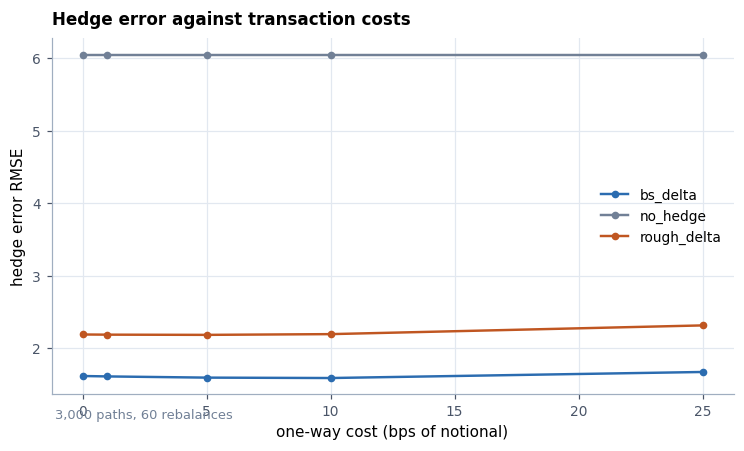

In [41]:
import matplotlib.pyplot as plt
from rvlab.plotting import PALETTE, finish

fig, ax = plt.subplots()
for i, (policy, grp) in enumerate(costs.groupby("policy")):
    ax.plot(grp["cost_bps"], grp["rmse"], marker="o", color=PALETTE[i], label=policy)
ax.legend()
finish(ax, "Hedge error against transaction costs", "one-way cost (bps of notional)",
       "hedge error RMSE", f"{S.shape[0]:,} paths, {N_STEPS} rebalances");

## R4.18 · Report the tail, not just the average
<a id="r4-18"></a>

**Topic** Risk metrics

**Use when** evaluating a hedge. A hedge is bought for its behaviour in bad states, so RMSE alone is the wrong summary. CVaR — the mean of the worst 5% — is the number that matters.

**Inputs** the per-path outcomes from the ledger.

**Needs** R4.15, R4.16, R4.17 — run those first. This recipe builds on what they define.

**Gotchas** two policies with identical RMSE and different CVaR are not equally good, and the one with the better average can easily be the one that ruins you.

**See also** [R4.17](#r4-17) (costs) · [R4.19](#r4-19) (turnover)

In [42]:
zero_cost = costs[costs["cost_bps"] == 0.0]
zero_cost[["policy", "rmse", "std", "q05", "cvar_05", "mean_turnover"]].round(4)

,policy,rmse,std,q05,cvar_05,mean_turnover
0,bs_delta,1.6200,1.5687,-2.2511,-3.7392,3.1205
1,rough_delta,2.1920,2.1538,-3.3357,-5.0070,3.5176
2,no_hedge,6.0483,6.0378,-11.7319,-15.7764,0.0000


Ranking the policies by tail risk rather than by average error. Hedging removes an enormous amount of tail risk relative to not hedging — that comparison is much larger than any difference between the two hedges.

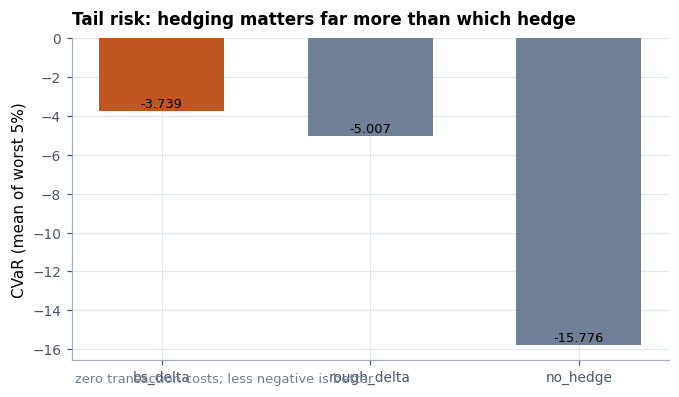

In [43]:
from rvlab.plotting import pnl_plot

pnl_plot(zero_cost, value_col="cvar_05", policy_col="policy",
         title="Tail risk: hedging matters far more than which hedge",
         ylabel="CVaR (mean of worst 5%)", lower_is_better=False,
         note="zero transaction costs; less negative is better");

## R4.19 · Account for turnover, not just error
<a id="r4-19"></a>

**Topic** Backtesting

**Use when** a hedge that is slightly more accurate but trades twice as much is not obviously better. Turnover is the quantity costs act on, so it belongs in the comparison.

**Inputs** the ledger summary.

**Needs** R4.15, R4.16, R4.17, R4.18 — run those first. This recipe builds on what they define.

**Gotchas** cost per unit of error reduction is the ratio that decides this, and it is rarely reported. A hedge earning its accuracy through turnover degrades fastest as costs rise.

**See also** [R4.17](#r4-17) (cost curve)

In [44]:
import pandas as pd

hedged = zero_cost[zero_cost["policy"] != "no_hedge"].set_index("policy")
unhedged_rmse = float(zero_cost.set_index("policy").loc["no_hedge", "rmse"])

pd.DataFrame({
    "rmse": hedged["rmse"].round(4),
    "turnover": hedged["mean_turnover"].round(3),
    "error_reduction": (unhedged_rmse - hedged["rmse"]).round(4),
    "turnover_per_unit_reduction": (hedged["mean_turnover"] /
                                    (unhedged_rmse - hedged["rmse"])).round(3),
})

,rmse,turnover,error_reduction,turnover_per_unit_reduction
policy,,,,
bs_delta,1.620,3.120,4.4283,0.705
rough_delta,2.192,3.518,3.8563,0.912


## R4.20 · Walk forward instead of splitting once
<a id="r4-20"></a>

**Topic** Backtesting

**Use when** you want the evaluation to look like production. Retrain on a fixed window of distinct timestamps, act on the next time block, roll forward, then map those timestamps back to panel rows. Every fold has the same number of training times even when coverage varies.

**Inputs** any frame with a time column.

**Needs** nothing beyond the setup and data cells

**Gotchas** split unique timestamps before mapping back to rows. A row-count window can put different entities from one timestamp on both sides; an expanding window can also make later folds look better simply because it contains more history.

**See also** [R3.11](forecasting_the_smile.ipynb#r3-11) (other splitters) · [R3.12](forecasting_the_smile.ipynb#r3-12) (embargo)

In [45]:
import numpy as np, pandas as pd
from types import SimpleNamespace
from rvlab.data import load_smile_panel
from rvlab.features import resample_panel
from rvlab.pipelines import WalkForwardSplit, describe_folds

walk_panel = resample_panel(load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE), 30)
unique_times = pd.DatetimeIndex(np.sort(pd.to_datetime(walk_panel["ts"], utc=True).unique()))
time_frame = pd.DataFrame({"ts": unique_times})
embargo_periods = 1
train_periods = max(2, int(len(unique_times) * 0.40))
test_periods = max(1, int(len(unique_times) * 0.10))
assert train_periods + embargo_periods + test_periods <= len(unique_times)
wf_times = WalkForwardSplit(train_size=train_periods + embargo_periods,
                            test_size=test_periods, embargo=embargo_periods)
time_folds = list(wf_times.split(time_frame))
row_times, mapped_folds = pd.to_datetime(walk_panel["ts"], utc=True), []
for tr_t, te_t in time_folds:
    tr_times, te_times = unique_times[tr_t], unique_times[te_t]
    mapped_folds.append((np.flatnonzero(row_times.isin(tr_times)),
                         np.flatnonzero(row_times.isin(te_times))))
wf = SimpleNamespace(split=lambda _: iter(mapped_folds))
folds = describe_folds(wf, walk_panel)
print(f"{len(walk_panel):,} rows at {len(unique_times)} timestamps; embargo {embargo_periods} timestamp")
folds.head(6)

11,880 rows at 1019 timestamps; embargo 1 timestamp


,fold,n_train,n_test,train_end,test_start,gap,overlap
0,0,4772,1180,2025-09-24 19:00:00+00:00,2025-09-25 14:00:00+00:00,0 days 19:00:00,False
1,1,4751,1118,2025-10-07 15:30:00+00:00,2025-10-07 16:30:00+00:00,0 days 01:00:00,False
2,2,4718,1108,2025-10-17 18:00:00+00:00,2025-10-17 19:00:00+00:00,0 days 01:00:00,False
3,3,4556,1186,2025-10-30 14:30:00+00:00,2025-10-30 15:30:00+00:00,0 days 01:00:00,False
4,4,4624,1176,2025-11-12 19:00:00+00:00,2025-11-13 15:00:00+00:00,0 days 20:00:00,False
5,5,4626,1274,2025-11-26 19:30:00+00:00,2025-11-28 15:30:00+00:00,1 days 20:00:00,False


The splitter holds the number of training and test **timestamps** constant. Row counts may vary as panel coverage changes; treating rows as the window unit would split entities observed at the same instant.

In [46]:
assert len(folds), "walk-forward configuration produced no folds"
assert not folds["overlap"].any()
assert (folds["gap"] > pd.Timedelta(0)).all()
assert all(not set(row_times.iloc[tr]) & set(row_times.iloc[te])
           for tr, te in mapped_folds)
assert all(int(te.min()) - int(tr.max()) - 1 == embargo_periods
           for tr, te in time_folds)
train_time_counts = [row_times.iloc[tr].nunique() for tr, _ in mapped_folds]
test_time_counts = [row_times.iloc[te].nunique() for _, te in mapped_folds]
assert set(train_time_counts) == {train_periods}
assert set(test_time_counts) == {test_periods}
print(f"{len(folds)} folds · train timestamps {train_periods} · test timestamps {test_periods}")
print(f"row-count ranges: train {folds['n_train'].min()}–{folds['n_train'].max()}, "
      f"test {folds['n_test'].min()}–{folds['n_test'].max()} · min safe gap {folds['gap'].min()}")

6 folds · train timestamps 407 · test timestamps 101
row-count ranges: train 4556–4772, test 1108–1274 · min safe gap 0 days 01:00:00


## R4.21 · Export the result so someone else can use it
<a id="r4-21"></a>

**Topic** Reporting

**Use when** the analysis is finished. Write tidy tables, the figures, and a manifest recording what produced them — together, in one directory.

**Inputs** the result frames and `rvlab.config.OUTPUT_DIR`.

**Needs** R4.15, R4.16, R4.17 — run those first. This recipe builds on what they define.

**Gotchas** tidy CSV rather than a formatted table: someone will want to re-plot it, and a table formatted for reading is a table that has to be parsed back. Keep the formatting in the notebook and the data in the file.

**See also** [R4.14](when_a_result_is_real.ipynb#r4-14) (sweep manifests) · [R1.7](the_volatility_surface.ipynb#r1-7) (provenance)

In [47]:
import json, sys
from rvlab.config import OUTPUT_DIR

costs.to_csv(OUTPUT_DIR / "hedge_cost_sensitivity.csv", index=False)
manifest = {
    "experiment": "rough vs BS delta hedge on simulated rough Bergomi paths",
    "n_paths": int(S.shape[0]), "n_rebalances": N_STEPS, "maturity": MATURITY,
    "rough_params": {"H": HURST, "eta": ETA, "rho": RHO, "xi0": XI0},
    "bs_hedger_sigma": SIGMA, "cost_bps": list(COST_BPS), "seed": SEED,
    "generator": df.attrs.get("generator", "rvlab fBM"), "python": sys.version.split()[0],
}
(OUTPUT_DIR / "hedge_manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2)[:420])

{
  "experiment": "rough vs BS delta hedge on simulated rough Bergomi paths",
  "n_paths": 3000,
  "n_rebalances": 60,
  "maturity": 0.25,
  "rough_params": {
    "H": 0.1,
    "eta": 1.5,
    "rho": -0.7,
    "xi0": 0.0625
  },
  "bs_hedger_sigma": 0.25,
  "cost_bps": [
    0.0,
    1.0,
    5.0,
    10.0,
    25.0
  ],
  "seed": 42,
  "generator": "roughvol.RoughBergomiModel[blp-hybrid]",
  "python": "3.12.0"
}


What ended up on disk. Data, figures and manifest together are the unit that survives the notebook — the joblib sweep cache is excluded, since it is a rebuildable artefact rather than a result.

In [48]:
from rvlab.config import CACHE_DIR, OUTPUT_DIR

for f in sorted(OUTPUT_DIR.rglob("*")):
    if f.is_file() and CACHE_DIR not in f.parents:
        print(f"  {f.relative_to(OUTPUT_DIR)}  ({f.stat().st_size / 1024:.1f} KB)")

  competition_workbench_13a49e39b5a5/fold_metrics.csv  (0.5 KB)
  competition_workbench_13a49e39b5a5/manifest.json  (2.1 KB)
  competition_workbench_13a49e39b5a5/model.joblib  (4.4 KB)
  competition_workbench_13a49e39b5a5/model_card.json  (0.4 KB)
  competition_workbench_13a49e39b5a5/oof_predictions.csv  (26.0 KB)
  competition_workbench_13a49e39b5a5/submission.csv  (2.4 KB)
  competition_workbench_25f0de26203b/adversarial_drift.csv  (0.2 KB)
  competition_workbench_25f0de26203b/categorical_novelty.csv  (0.1 KB)
  competition_workbench_25f0de26203b/cv_scores.csv  (0.3 KB)
  competition_workbench_25f0de26203b/development_target_proxy_scan.csv  (0.0 KB)
  competition_workbench_25f0de26203b/diagnostic_fold_path.csv  (0.1 KB)
  competition_workbench_25f0de26203b/diagnostic_residual.csv  (0.2 KB)
  competition_workbench_25f0de26203b/final_holdout_predictions.csv  (3.2 KB)
  competition_workbench_25f0de26203b/final_holdout_score.csv  (0.1 KB)
  competition_workbench_25f0de26203b/fold_assignm

## R4.22 · Write down the result, including when it is negative
<a id="r4-22"></a>

**Topic** Reporting

**Use when** the end of any study. State the claim, the evidence, the caveat and what would change your mind — in that order. A negative result written this way is more useful than a positive one written vaguely.

**Inputs** the findings from the whole series.

**Needs** R4.9, R4.12, R4.18 — run those first. This recipe combines robustness and hedge evidence.

**Gotchas** the failure mode is upgrading an exploratory result into a validated one by writing about it confidently. Attach the evidence tier to the claim itself, so it cannot be separated from it later.

**See also** [R4.14](when_a_result_is_real.ipynb#r4-14) (manifests) · [R3.21](forecasting_the_smile.ipynb#r3-21) (multiplicity)

In [49]:
import pandas as pd

raw_pass = int((results["skill_rough"] > 0).sum())
cond_pass = int((results["skill_cond"] > 0).sum())
active_skill = regime_results.loc[
    regime_results["regime"].str.startswith("active"), "skill_out_of_fold"]
hedge = zero_cost.set_index("policy")
rough_hedge_wins = (hedge.loc["rough_delta", "rmse"] < hedge.loc["bs_delta", "rmse"]
                    and hedge.loc["rough_delta", "cvar_05"] > hedge.loc["bs_delta", "cvar_05"])
findings = pd.DataFrame([
    ("H1 skew scaling", "see provenance-tagged source result",
     "R2.9 owns the fitted slope, uncertainty and data source; do not copy a verdict across modes"),
    ("H2 raw rough forecast", "broad-grid rejection" if raw_pass == 0 else "mixed broad-grid evidence",
     f"raw {raw_pass}/{len(results)} and conditioned {cond_pass}/{len(results)} cells beat carry"),
    ("H3 regime conditioning", "positive OOF skill" if overall_oof_skill > 0 else "non-positive OOF skill",
     f"overall {overall_oof_skill:+.1%}; active-cutoff range {active_skill.min():+.1%} to {active_skill.max():+.1%}"),
    ("H4 rough delta hedge", "beats BS on both metrics" if rough_hedge_wins else "does not beat BS on both metrics",
     f"zero-cost RMSE BS/rough {hedge.loc['bs_delta','rmse']:.3f}/{hedge.loc['rough_delta','rmse']:.3f}; "
     f"CVaR {hedge.loc['bs_delta','cvar_05']:.3f}/{hedge.loc['rough_delta','cvar_05']:.3f}"),
    ("Carry-conditioned forecast", "active-run estimate",
     f"OOF skill {overall_oof_skill:+.1%}; use R3.17 for the separate learned-model ledger"),
], columns=["claim", "evidence tier", "basis"])
findings

,claim,evidence tier,basis
0,H1 skew scaling,see provenance-tagged source result,"R2.9 owns the fitted slope, uncertainty and da..."
1,H2 raw rough forecast,broad-grid rejection,raw 0/30 and conditioned 0/30 cells beat carry
2,H3 regime conditioning,non-positive OOF skill,overall -0.2%; active-cutoff range -4.0% to -1.5%
3,H4 rough delta hedge,does not beat BS on both metrics,zero-cost RMSE BS/rough 1.620/2.192; CVaR -3.7...
4,Carry-conditioned forecast,active-run estimate,OOF skill -0.2%; use R3.17 for the separate le...


> The rule this table encodes: **the evidence tier travels with the claim.** Writing 'the rough delta hedge showed no improvement' is complete; writing 'we tested the rough delta hedge' invites someone to fill in the result themselves, and they will fill it in favourably.

In [50]:
print("What would change these conclusions:")
for line in [
    "H1: a longer panel with wider maturity coverage, or a term-structure-aware estimator",
    "H2: a materially different feature transform, tested on an untouched holdout",
    "H3: a regime definition fixed in advance, not selected from the same sample",
    "H4: hedging real market paths rather than the model's own, with realistic quotes",
]:
    print(f"  - {line}")

What would change these conclusions:
  - H1: a longer panel with wider maturity coverage, or a term-structure-aware estimator
  - H2: a materially different feature transform, tested on an untouched holdout
  - H3: a regime definition fixed in advance, not selected from the same sample
  - H4: hedging real market paths rather than the model's own, with realistic quotes


## Verdict & what carries forward

Three attacks on the same result. The active tables, rather than fixed historical numbers,
decide which claims survive attribution, robustness and the economic test.

### Which feature was doing the work

Attribution is deliberately reported at more than one resolution.

* **Individual and grouped importance answer different questions.** [R4.1](#r4-1) prints
  the active run's leading column; [R4.3](#r4-3) prints the leading correlated family and
  the measured damage from removing the rough-structural block. Those rows own the ordering.
* **Partial dependence is conditional on correlated siblings.** The slopes printed in
  [R4.4](#r4-4) distinguish moving `bf25` alone from moving its whole family; no fixed
  'one-for-one' label is substituted for those estimates.
* **PCA reports its own explained shares.** The active [R4.6](#r4-6) table says how dominant
  PC1 is and the loadings identify level, slope and curvature without hard-coding 97%.
* **Clustering always returns clusters.** [R4.7](#r4-7) is the general warning: without the
  noise control there is no way to tell a regime from an arbitrary partition of one blob.

These diagnostics should be read beside the provenance-tagged outputs in [What Roughness Claims](what_roughness_claims.ipynb) and [Forecasting the Smile](forecasting_the_smile.ipynb). A synthetic fallback demonstrates the method; it does not establish a SPY exponent or reproduce a registry verdict.

The next section tests whether that conditioned correction is stable across frequencies,
tenor filters and regimes, without choosing any threshold from future observations.

Next in this notebook: **Does the model hold anywhere?**.

### Does the model hold anywhere?

The robustness result stays attached to the active grid and its provenance.

* **The broad-grid counts are descriptive evidence.** [R4.10](#r4-10) shows every sign and
  [R4.11](#r4-11) prints exact raw and carry-conditioned pass counts. Correlated cells do not
  turn that fraction into a binomial significance test.
* **Regime claims come from OOF rows only.** [R4.12](#r4-12) computes moves from past bars,
  estimates each cutoff on the preceding training fold, and prints overall plus active/quiet
  skills. The displayed signs and ranges determine whether any regime advantage exists.
* **Tenor sensitivity is a separate family of tests.** [R4.13](#r4-13) prints its exact pass
  counts. If its conclusion differs from the broad panel, report the scope rather than merging
  the grids after seeing the answer.

The economic hedge test remains necessary: forecast skill alone, whatever its magnitude,
does not establish a tradeable edge.

One question remains, and it is the one that would matter even if everything above had gone
the other way: does any of this survive a hedge, with costs?

Next in this notebook: **The hedging test, and reporting what you found**.

### The hedging test, and reporting what you found

**The current zero-cost table compares both hedges on the rough model's own simulated paths.**

That last clause matters. These paths were generated *by* a rough Bergomi model, with the
hedger given the true parameters. [R4.22](#r4-22) derives its verdict from the displayed
rough-versus-BS RMSE and CVaR, so the conclusion cannot outlive a changed simulation output.

**Part I, end to end:**

| Question | Answer |
|---|---|
| Does the skew scale as rough volatility predicts? | Read the fitted slope, interval and provenance together ([R2.9](what_roughness_claims.ipynb#r2-9)) |
| Can rough structure forecast the next smile? | Read active-run skill from the single OOF ledger and the broad-grid counts ([R3.17](forecasting_the_smile.ipynb#r3-17), [R4.10](#r4-10)) |
| Does it work in some regime? | Compare the printed active and quiet OOF skills for every predeclared cutoff ([R4.12](#r4-12)) |
| Does it hedge better? | Compare rough and BS RMSE plus CVaR on the shared simulated paths ([R4.16](#r4-16), [R4.18](#r4-18)) |
| What *did* work? | The `findings` table above records only conclusions supported by the current outputs |

**What the exercise was worth.** A negative result obtained with correct baselines, honest
cross-validation and multiplicity awareness is a real contribution — and considerably more
useful than a positive one produced by searching a grid until something passed. The most
transferable thing here is [R4.12](when_a_result_is_real.ipynb#r4-12): the
same model and held-out regime rows, with thresholds estimated only from each preceding
training fold and in-sample versus OOF scores shown side by side.

**As a template.** Every recipe in this nine-notebook series is indexed in
[`README.md`](README.md), self-contained, and verified to run standalone by
`scripts/lint_notebooks.py --copy-paste-test`.

---

### That is Part I — one hypothesis, taken to a verdict

The arc was: state what the model claims and estimate its parameter in
[What Roughness Claims](what_roughness_claims.ipynb), build leak-free features, establish a benchmark,
validate and score it in [Forecasting the Smile](forecasting_the_smile.ipynb), ask what the model actually used,
test whether it holds anywhere, and finally test it economically here rather
than statistically (here). Any hypothesis about a market can be put through that sequence;
rough volatility is the one worked in full because it fails, and a failure shows the machinery
working.

**Part II**, [The Cross-Section](the_cross_section.ipynb),
runs the same methodology under a different research design — many entities on one date
instead of one series through time, which changes the estimand, the validation and the metric.
**Part III**, from [Where the Numbers Come From](where_the_numbers_come_from.ipynb) through [Measuring and Trading Volatility](measuring_and_trading_volatility.ipynb), takes the
techniques these two parts leaned on and treats each on its own terms, including the
volatility estimators themselves. **Part IV**, the [Competition Workbench](competition_workbench.ipynb), routes those reusable checks by IID, grouped, temporal or panel geometry and carries one OOF ledger through selection, refit and submission.

Next: [The Cross-Section](the_cross_section.ipynb).